In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

import tqdm as tqdm

In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 14,                          # Standard font size for scientific papers
    "axes.labelsize": 14,                     # Size of the x and y axis labels
    "xtick.labelsize": 12,                     # Size of the x-tick labels
    "ytick.labelsize": 12,                     # Size of the y-tick labels
    "legend.fontsize": 12,                     # Size of the legend text
    "figure.titlesize": 16                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
# =======================
# BASE COSMOLOGY: Planck 2015 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.041783
omega_b     = 0.022383
omega_cdm0  = 0.12011
tau_reio    = 0.0543
A_s         = 2.1005829616811546e-9
n_s         = 0.96605

base_params = {
    "theta_s_100": theta_s_100,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,
}

In [4]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set(base_params)
lcdm.set({ 'output': 'tCl,pCl,lCl',
          'lensing': 'yes',
          'l_max_scalars': 2500,
          # add neutrinos to make it more realistic
        #   'N_ncdm': 1,
        #   'deg_ncdm': 3, # 3 neutrino species
        #   'm_ncdm': 0.02, # in eV, set a small mass for the neutrino to avoid issues with the early universe
        #   'T_ncdm': 0.71611, # T_ncdm/T_cmb, set to the standard value for neutrinos
        #   'N_ur': 0.00441, # no massless neutrinos
          })
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
rho_nu_lcdm = bg_lcdm['(.)rho_ur']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")


Redshift of matter-radiation equality in LCDM: 3405.82


In [5]:
### Constants

num_of_gigayears = 0.1 # REMOVE, Irrelevant in this formulation
tau_acc = num_of_gigayears*3600*24*365*1e9 # REMOVE, Irrelevant in this formulation
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e16
m_wdm = 1e16 # in accDM model it should be the same as mass of the DM particle before acceleration, but this implementation is more general and allows to set them independently
kappa = 12
a_t = 0.13
eps = 0.1

In [7]:
### Run CLASS ###

# Output dictionaries
AccCLASS = {}
bgAcc = {}
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, p_acc = {}, {}
smooth_rho_acc, smooth_p_acc = {}, {}
rho_nu = {}
rho_tot, rho_crit = {}, {}
z_eq = {}

eta_list = [1e-2, 1e-1, 1]

for eta in tqdm.tqdm(eta_list):
    if (m_wdm*(1+eta) > 1e19) or (m_dcdm > 1e19):
        print(f"Warning: energy of the WDM particle after acceleration is {m_wdm*(1+eta):.2e} GeV, which is above the Planck scale.")
        break
    
    AccCLASS = Class()
    AccCLASS.set(base_params)
    AccCLASS.set({  'output': 'tCl,pCl,lCl',
                    'lensing': 'yes',
                    'l_max_scalars': 2500,
                    # accDM params
                    'vary_Gamma_wdm': 'yes',               # Use the more general formulation
                    'kappa_mon':      kappa,               # 
                    'a_t_mon':        a_t,                 # Scale factor at which the acceleration happens
                    'f_wdm':          f_acc,               # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                    'eta_wdm':        eta,                 # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\eta)
                    "tau_wdm":        tau_acc,             # REMOVE, Irrelevant in this formulation, but set it to a large value to avoid issues with the code, since we are not using the decay formulation
                    "m_wdm_in_GeV":   m_wdm,               # accDM mass in GeV
                    "m_cdm_in_GeV":   m_dcdm,              # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
                    # ncdm params [0] is for the neutrinos, [1] is for the WDM component
                    "N_ncdm":                   2,                       # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM in the ncdm sector
                    "deg_ncdm":                 "3, 1",                  # 3 neutrino species and 1 degrees of freedom for the WDM component 
                    "m_ncdm":                   f"0.02, {m_wdm*1e9}",    # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
                    "T_ncdm":                   "0.71611, 1",            # Set the same temperature for the WDM component as for the neutrinos,
                    "N_ur":                     0.00441,                 # Set the number of massless neutrino species to 0 since we are including them as ncdm species
                    "ncdm_quadrature_strategy": "0, 4",                  # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)
                    "ncdm_N_momentum_bins" :    "15, 101",              # Set a higher number of momentum bins for the WDM component, maybe the same number as evolution steps? But that's 40000, so a lot. FOR SIMPSION THE NUBMER OF MOMENTUM BINS SHOULD BE ODD, CHECK THIS
                    # precision
                    'reionization_z_start_max': 80,      # Default is 50, 80 is the minimal value that works for the chosen eta values if we set tau_reio to Planck 2018 value, it just widens the bracket so that this doesn't cause issue with shooting for h
                    'evolver': 0
                    })
    AccCLASS.compute()
    bgAcc[eta] = AccCLASS.get_background()
    
    # a, z, and H
    H[eta] = bgAcc[eta]['H [1/Mpc]']
    z[eta] = bgAcc[eta]['z']
    a[eta] = 1/(1+z[eta])
    
    # The usual components of the universe
    rho_g[eta] = bgAcc[eta]['(.)rho_g'] 
    rho_b[eta] = bgAcc[eta]['(.)rho_b']
    rho_cdm[eta] = bgAcc[eta]['(.)rho_cdm']
    rho_lambda[eta] = bgAcc[eta]['(.)rho_lambda']
    rho_ur[eta] = bgAcc[eta]['(.)rho_ur']
    rho_nu[eta] = bgAcc[eta]['(.)rho_ncdm[0]']

    # Energy densities of the DCDM and WDM components and the pressure of the WDM component
    rho_dcdm[eta] = bgAcc[eta]['(.)rho_dcdm']
    rho_acc[eta] = bgAcc[eta]['(.)rho_ncdm[1]']
    p_acc[eta] = bgAcc[eta]['(.)p_ncdm[1]']

    # Total and critical energy densities
    rho_tot[eta] = bgAcc[eta]['(.)rho_tot']
    rho_crit[eta] = bgAcc[eta]['(.)rho_crit']
    
    z_eq[eta] = AccCLASS.get_current_derived_parameters(['z_eq'])

    # Smooth rho_acc and p_acc to avoid wiggles in plots
    smooth_rho_acc[eta] = gaussian_filter1d(rho_acc[eta], sigma=20)
    smooth_p_acc[eta] = gaussian_filter1d(p_acc[eta], sigma=20)

  0%|          | 0/3 [00:05<?, ?it/s]


CosmoComputationError: 

Error in Class: operator()(L:955) :error in perturbations_solve(ppr, pba, pth, ppt, index_md, index_ic, index_k, &pw);
=>perturbations_solve(L:3272) :error in generic_evolver(perturbations_derivs, interval_limit[index_interval], interval_limit[index_interval+1], ppw->pv->y, ppw->pv->used_in_sources, ppw->pv->pt_size, &ppaw, ppr->tol_perturbations_integration, ppr->smallest_allowed_variation, perturbations_timescale, ppr->perturbations_integration_stepsize, ppt->tau_sampling, tau_actual_size, perturbations_sources, perhaps_print_variables, ppt->error_message);
=>evolver_rk(L:110) :error in generic_integrator(derivs, x1, x2, y, parameters_and_workspace_for_derivs, tolerance, x1*minimum_variation, &gi);
=>generic_integrator(L:117) :condition (fabs(hnext/x1) <= hmin) is true; Step size too small: step:7.37435e-13, minimum:1.69773e-12, in interval: [7645.88:7713.83]

In [ ]:
for eta in eta_list:
    print(f"Redshift of matter-radiation equality in accDM model with eta={eta}: {z_eq[eta]['z_eq']:.2f}")

Redshift of matter-radiation equality in accDM model with eta=0.01: 3693.32
Redshift of matter-radiation equality in accDM model with eta=0.1: 3693.32
Redshift of matter-radiation equality in accDM model with eta=1: 3693.32


<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_61875/2945187954.py:19: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Relativistic part of accDM for different values of $\eta$')


Plotting for eta = 0.01
3693.3189422255073
Plotting for eta = 0.1
3693.3189422255073
Plotting for eta = 1
3693.3189422255073


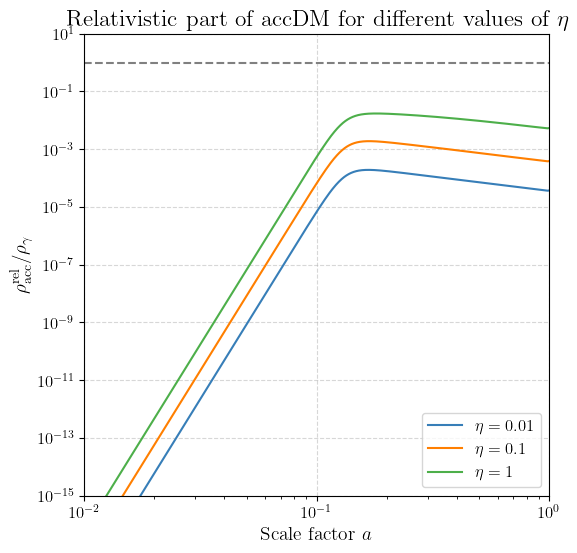

In [ ]:
### Plot relativistic pressure of accDM for different values of eta
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

for eta in eta_list:
    print(f'Plotting for eta = {eta}')
    a_acc = a[eta]
    
    ax.plot(a_acc, 3*smooth_p_acc[eta]*a_acc**4/rho_cdm[eta][-1], label=r'$\eta = {}$'.format(eta), ls = '-', color=colors_colorblind[eta_list.index(eta)])
    
    ax.set_ylabel(r'$\rho_\mathrm{acc}^\mathrm{rel}/\rho_\gamma$')
    ax.set_xlabel(r'Scale factor $a$')
    print(z_eq[eta]['z_eq'])

ax.axhline(1, color='grey', linestyle='--')

ax.legend()
ax.set_title('Relativistic part of accDM for different values of $\eta$')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-15, 10)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)
# ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_61875/3023849085.py:19: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Cold part of the total DM density compared to LCDM for different $\eta$')


Plotting for eta = 0.01
3693.3189422255073
Plotting for eta = 0.1
3693.3189422255073
Plotting for eta = 1
3693.3189422255073


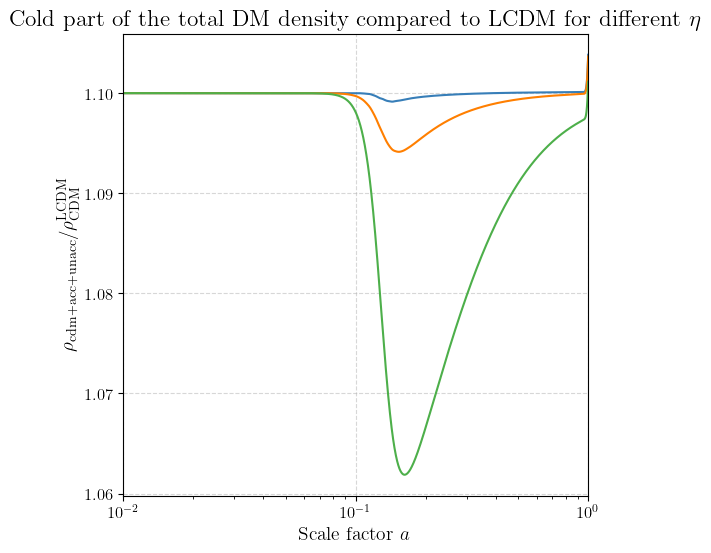

In [ ]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

rho_cdm_lcdm_interp = interp1d(a_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

for eta in eta_list:
    print(f'Plotting for eta = {eta}')
    a_acc = a[eta]
    
    cold_rho_acc = smooth_rho_acc[eta]-3*smooth_p_acc[eta]
    
    ax.plot(a_acc, (rho_dcdm[eta]+rho_cdm[eta]+cold_rho_acc)/rho_cdm_lcdm_interp(a_acc), ls = '-', color=colors_colorblind[eta_list.index(eta)])
    
    ax.set_ylabel(r'$\rho_\mathrm{cdm+acc+unacc}/\rho_\mathrm{CDM}^{\mathrm{LCDM}}$')
    ax.set_xlabel(r'Scale factor $a$')
    print(z_eq[eta]['z_eq'])

# ax.legend()
ax.set_title('Cold part of the total DM density compared to LCDM for different $\eta$')
ax.set_yscale('linear')
ax.set_xscale('log')
# ax.set_ylim(0.9, 1.01)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)
# ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')


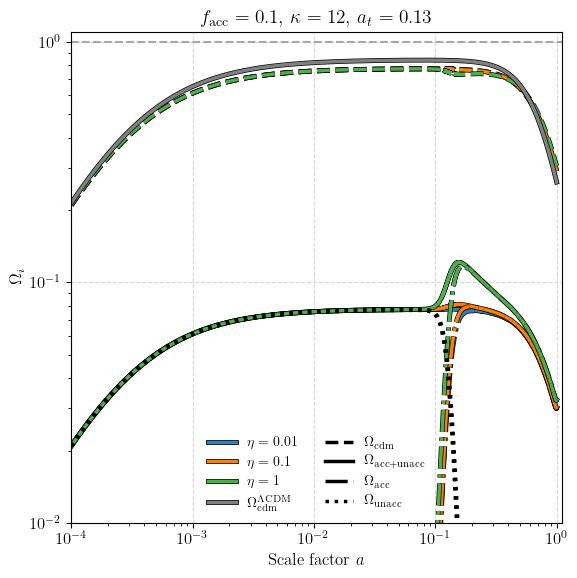

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

outline = [pe.withStroke(linewidth=3.5, foreground='black')]
line_w = 2.5

for idx, eta in enumerate(eta_list):
    a_acc = a[eta]
    c = colors_colorblind[idx % len(colors_colorblind)] # Safe indexing in case eta_list > colors
    
    # cdm = solid (-), acc = dotted (:), dcdm = dashed (--)
    ax.plot(a_acc, rho_cdm[eta]/rho_tot[eta], 
              linewidth=line_w, ls='--', path_effects=outline, color=c)
    ax.plot(a_acc, (rho_dcdm[eta]+smooth_rho_acc[eta])/rho_tot[eta], 
              linewidth=line_w, ls='-', path_effects=outline, color=c, label=rf'$\eta = {eta}$')
    ax.plot(a_acc, smooth_rho_acc[eta]/rho_tot[eta], 
              linewidth=line_w, ls='-.', path_effects=outline, color=c)
    
    Omega_dm_tot = rho_cdm[eta]/rho_tot[eta] + rho_dcdm[eta]/rho_tot[eta]
    Omega_dm_acc = Omega_dm_tot + rho_acc[eta]/rho_tot[eta]
    # print(f"Omega_dm (without acc) today for eta = {eta}: {Omega_dm_tot[-1]:.4f}")
    # print(f"Omega_dm (with acc) today for eta = {eta}: {Omega_dm_acc[-1]:.4f}")

ax.plot(a_acc, rho_dcdm[eta]/rho_tot[eta], 
        linewidth=line_w, ls=':', path_effects=outline, color='black')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'$\Omega_i$', fontsize=12)
ax.set_xlabel(r'Scale factor $a$', fontsize=12)

ax.set_ylim(1e-2, 1.1)
ax.set_xlim(1e-4, 1.1)

ax.axhline(1, color='grey', linestyle='--', zorder=0, alpha=0.7)

# Lambda CDM Reference Plot
ax.plot(a_lcdm, rho_cdm_lcdm/rho_tot_lcdm, label=r'$\Omega_{\mathrm{cdm}}^{\Lambda\mathrm{CDM}}$', 
          linewidth=line_w, ls='-', path_effects=outline, color='grey')

handles, labels = ax.get_legend_handles_labels()

style_handles = [
    Line2D([0], [0], color='black', lw=line_w, ls='--', label=r'$\Omega_{\mathrm{cdm}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls='-', label=r'$\Omega_{\mathrm{acc}+\mathrm{unacc}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls='-.', label=r'$\Omega_{\mathrm{acc}}$'),
    Line2D([0], [0], color='black', lw=line_w, ls=':', label=r'$\Omega_{\mathrm{unacc}}$'), 
]

ax.legend(handles=handles + style_handles, loc='best', fontsize=10, frameon=False, ncol=2)

ax.grid(ls='--', alpha=0.5)

ax.set_title(rf'$f_{{\text{{acc}}}} = {f_acc}$, $\kappa = {kappa}$, $a_t = {a_t}$', fontsize=14)

plt.tight_layout()
plt.show()

w_acc today for eta = 0.01: 0.0001
w_acc today for eta = 0.1: 0.0012
w_acc today for eta = 1: 0.0168


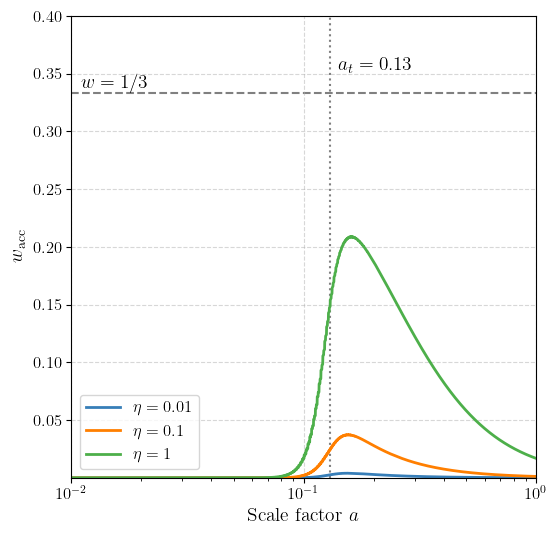

In [ ]:
### Plot equation of state of accDM for different values of eta
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

colors = colors_colorblind

for eta in eta_list:
    a_acc = a[eta]
    
    w_acc_plot = p_acc[eta]/(rho_acc[eta]+rho_dcdm[eta])
    print(f"w_acc today for eta = {eta}: {w_acc_plot[-1]:.4f}")
    
    ax.semilogx(a_acc, w_acc_plot, label=r'$\eta = {}$'.format(eta), linewidth=2, ls = '-', color = colors_colorblind[eta_list.index(eta)])

    ax.set_ylabel(r'$w_\mathrm{acc}$')
    ax.set_xlabel(r'Scale factor $a$')

ax.axvline(a_t, color='gray', linestyle=':', zorder=-1)
ax.text(a_t+0.01, 0.35, r'$a_t={}$'.format(a_t), color='black', fontsize=14, zorder=-1, ha = 'left', va = 'bottom')

ax.axhline(1/3, color='grey', linestyle='--', zorder=-1)
ax.text(1.1e-2, 1/3, r'$w=1/3$', color='black', fontsize=14, zorder=-1, ha = 'left', va = 'bottom')

ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, 0.4)
ax.set_xlim(1e-2, 1)
ax.grid(ls = '--', alpha = 0.5)

Ratio at z=0:  0.9496618665689938
Ratio at z=0:  0.9477671506531966
Ratio at z=0:  0.9258096644476448


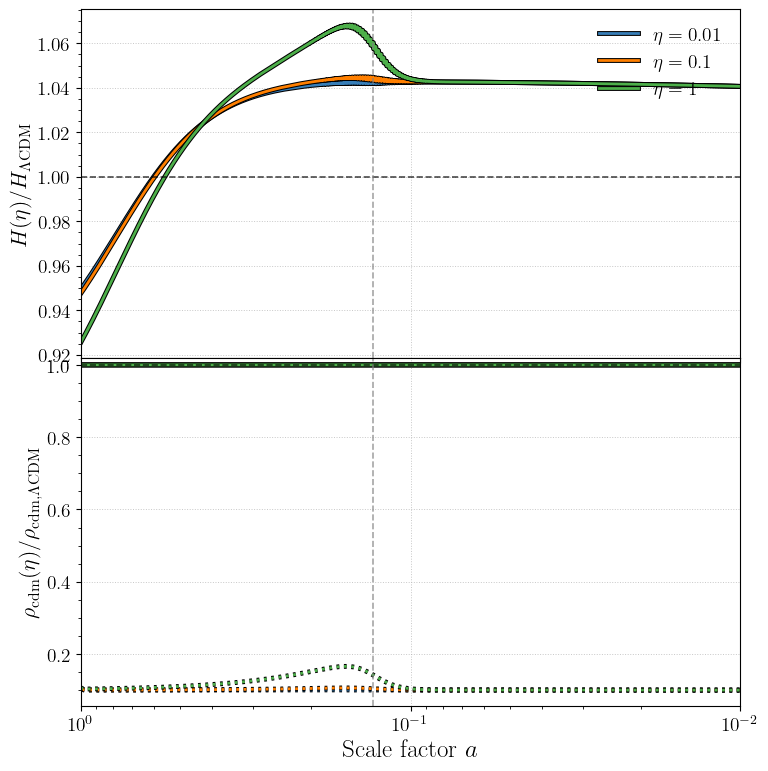

In [ ]:
# Set up figure
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Interpolation functions
interp_H_lcdm = interp1d(a_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_rho_cdm_lcdm = interp1d(a_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

colors = colors_colorblind

# Loop over eta values
for i, eta in enumerate(eta_list):
    z_mon = z[eta]
    a_mon = a[eta]
    H_mon = H[eta]
    rho_cdm_mon = rho_cdm[eta]
    rho_acc_mon = smooth_rho_acc[eta]
    rho_dcdm_mon = rho_dcdm[eta]

    # Interpolated LCDM quantities onto a[eta] grid
    H_lcdm_interp = interp_H_lcdm(a_mon)
    rho_cdm_lcdm_interp = interp_rho_cdm_lcdm(a_mon)

    color = colors[i]
    
    # Plot 1: H / H_lcdm
    axs[0].semilogx(a_mon, H_mon / H_lcdm_interp, 
                    linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                    label=rf'$\eta={eta}$', color=color)

    print('Ratio at z=0: ', H_mon[-1]/H_lcdm_interp[-1])
    axs[0].axvline(x=1/(1+z_eq[eta]['z_eq']), linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # a_eq

    # Plot 2: rho_cdm / rho_cdm_lcdm
    axs[1].semilogx(a_mon, rho_cdm_mon / rho_cdm_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
    axs[1].semilogx(a_mon, (rho_dcdm_mon+rho_acc_mon) / rho_cdm_lcdm_interp, linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color, ls=':')

    axs[1].set_ylim(None, 1.02)
    axs[1].axvline(x=1/(1+z_eq[eta]['z_eq']), linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # a_eq

    
# Common plot settings
titles = [
    r'$H(\eta)/H_{\Lambda\mathrm{CDM}}$',
    r'$\rho_{\mathrm{cdm}}(\eta)/\rho_{\mathrm{cdm},\Lambda\mathrm{CDM}}$',
]

for i, ax in enumerate(axs):
    ax.set_ylabel(titles[i], fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axvline(x=a_t, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)  # a_t line
    ax.set_xlim(1, 1e-2)
    if i == 0:
        ax.legend(fontsize=14, loc='upper right', frameon=False)

# X-axis label only on bottom plot
axs[-1].set_xlabel(r'Scale factor $a$', fontsize=18)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)

plt.show()

# Save the figure
fig.savefig('monopole_background.pdf', dpi=300, bbox_inches='tight')

Note that in our case $\rho_{crit}=\rho_{tot}$ as we consider flat FRW $K=0$ and for each $\eta$ it's identical as we force it that way by setting the same $h$.


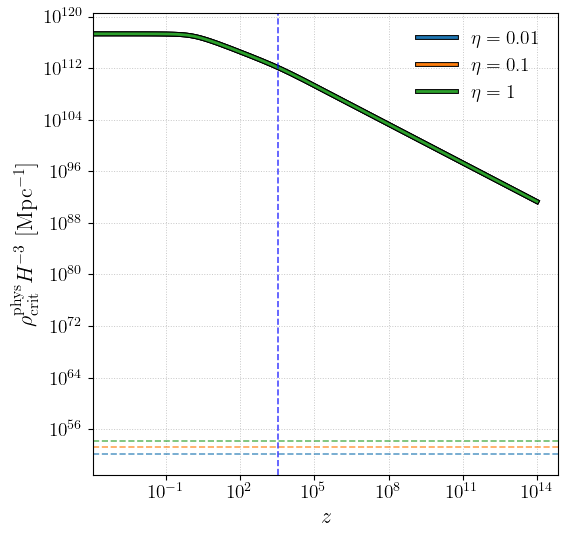

In [ ]:
### Plot rho_crit*H^(-3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

GeV_in_Mpc = 1.56374e38 # GeV in Mpc^-1
CLASS_to_phys = 4.35093e113 # 3/(8*pi*G) in Mpc^-2, conversion factor to go from CLASS units to physical units for energy densities

for eta in eta_list:
    z_mon = z[eta]
    H_mon = H[eta]  # in Mpc^-1
    rho_crit_acc = rho_crit[eta] # in Mpc^-2
    rho_crit_physical = rho_crit_acc * CLASS_to_phys # in Mpc^-4

    ax.loglog(z_mon, rho_crit_physical * H_mon**(-3), label=rf'$\eta={eta}$', linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color='C{}'.format(eta_list.index(eta)))
    ax.axhline(y=eta*m_wdm*GeV_in_Mpc, color='C{}'.format(eta_list.index(eta)), linestyle='--', linewidth=1.2, alpha=0.7)
    
ax.set_xlabel(r'$z$', fontsize=16)
ax.set_ylabel(r'$\rho_{\mathrm{crit}}^\mathrm{phys}H^{-3}$ [Mpc$^{-1}$]', fontsize=16)
ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14)
# ax.axvline(x=6, color='gray', linestyle='--', linewidth=1.2, alpha=0.7) 
ax.axvline(x=1+3400, color='blue', linestyle='--', linewidth=1.2, alpha=0.7)  # z_eq line
# ax.set_xlim(0.1, 2e5)
# ax.set_ylim
ax.legend(fontsize=14, loc='upper right', frameon=False)

So it seems that all $\eta$ are allowed and we'd need to go to some extremaly large value to break it. But I may be misunderstanding this. 